### 1.Imports

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

### 2.Dados do csv

In [3]:
# Importando os dados do arquivo CSV
df = pd.read_csv('investidores.csv')

# Exibindo as primeiras linhas do DataFrame para verificar os dados
print(df.head())

# Verificando informações gerais sobre o DataFrame
print(df.info())

# Regra para determinar a taxa de retorno com base no perfil do investidor
def calcular_taxa(tolerancia_risco):
    taxas = { 1: 0.02, 2: 0.04, 3: 0.06, 4: 0.08, 5: 0.10}

    return taxas[tolerancia_risco]

# Criando taxa
df['taxa_retorno'] = df['tolerancia_risco'].apply(calcular_taxa)

# Convertendo meses para anos
df['tempo_banco_anos'] = df['tempo_banco_meses'] / 12

# Retorno acumulado
df['Retorno_Acumulado'] = (
    df['saldo_investido'] *
    ((1 + df['taxa_retorno']) ** df['tempo_banco_anos'])
) - df['saldo_investido']

# Volatilidade simulada
df['Volatilidade'] = (
    df['tolerancia_risco'] *
    np.random.uniform(0.01, 0.05, len(df))
)

# Resultado
print(df.head())

   id_investidor  idade  saldo_investido  tempo_banco_meses  tolerancia_risco  \
0              1     28        510826.85                164                 2   
1              2     22        817675.60                318                 2   
2              3     48        442927.76                115                 5   
3              4     20        947174.43                338                 4   
4              5     34        356757.80                126                 2   

   renda_mensal  objetivo_principal  
0      41287.36            educacao  
1      37440.84              viagem  
2      22875.22        casa_propria  
3      19274.79  reserva_emergencia  
4      20932.65       aposentadoria  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_investidor       800 non-null    int64  
 1   idade               800 non-n

### 3. Evolução do patrimônio em gráfico

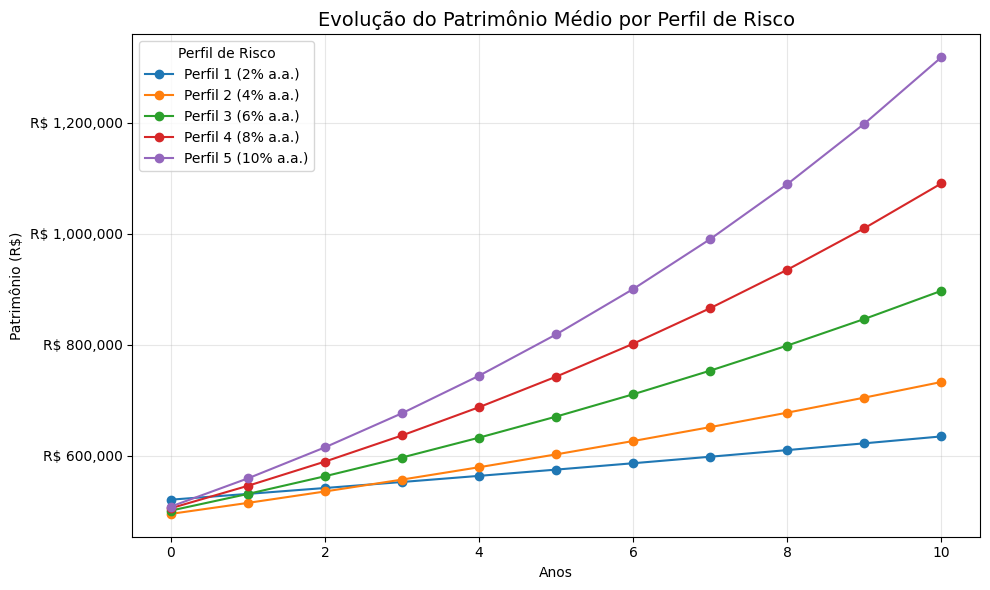

In [4]:
# Definindo as variaveis do gráfico
anos = np.arange(0, 11)
perfis = {1: 0.02, 2: 0.04, 3: 0.06, 4: 0.08, 5: 0.10}
saldo_medio = df.groupby('tolerancia_risco')['saldo_investido'].mean()

# Calculando patrimônio
fig, ax = plt.subplots(figsize=(10, 6))
for perfil, taxa in perfis.items():
    saldo_base = saldo_medio.get(perfil, 20000)
    patrimonio = saldo_base * (1 + taxa) ** anos
    ax.plot(anos, patrimonio, marker='o', label=f'Perfil {perfil} ({taxa*100:.0f}% a.a.)')

# Definindo propriedades do gráfico
ax.set_title('Evolução do Patrimônio Médio por Perfil de Risco', fontsize=14)
ax.set_xlabel('Anos')
ax.set_ylabel('Patrimônio (R$)')
ax.legend(title='Perfil de Risco')
ax.grid(True, alpha=0.3)

# Formatando o valor do patrimônio
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

# Plotando gráfico
plt.tight_layout()
plt.show()

### 4. Gráfico de relações

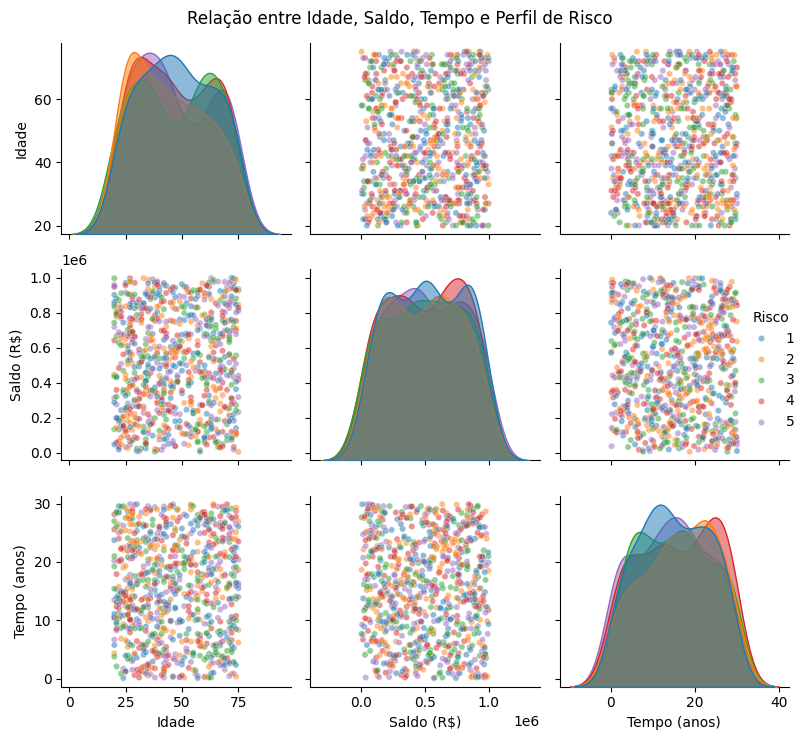

In [5]:
# Definindo valor das variaveis
df_plot = df[['idade', 'saldo_investido', 'tempo_banco_anos', 'tolerancia_risco']].copy()
df_plot.columns = ['Idade', 'Saldo (R$)', 'Tempo (anos)', 'Risco']
df_plot['Risco'] = df_plot['Risco'].astype(str)  # hue categórico

# Configurando gráfico
g = sns.pairplot(
    df_plot,
    hue='Risco', # Variavel que define o perfil do investidor
    hue_order=['1','2','3','4','5'],
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kws={'alpha': 0.5},
    corner=False
)

# Suptitle do gráfico
g.figure.suptitle('Relação entre Idade, Saldo, Tempo e Perfil de Risco')

# Plotando gráfico
plt.tight_layout()
plt.show()

### 5. Segmentação K-Means

In [26]:
features = ['idade', 'saldo_investido', 'tempo_banco_meses', 'tolerancia_risco', 'renda_mensal']
X = df[features]

display(X.head())  # confere se ficou certo

# Normaliza pra todas as colunas terem o mesmo peso
scaler = StandardScaler()
X_normalizado = scaler.fit_transform(X)

# Olha como ficaram os números agora (média ~0, desvio ~1)
print("Antes (primeira linha):", X.iloc[0].values)
print("Depois (primeira linha):", X_normalizado[0])

,idade,saldo_investido,tempo_banco_meses,tolerancia_risco,renda_mensal
0,28,510826.85,164,2,41287.36
1,22,817675.60,318,2,37440.84
2,48,442927.76,115,5,22875.22
3,20,947174.43,338,4,19274.79
4,34,356757.80,126,2,20932.65


Antes (primeira linha): [2.8000000e+01 5.1082685e+05 1.6400000e+02 2.0000000e+00 4.1287360e+04]
Depois (primeira linha): [-1.11505487  0.01613033 -0.19125476 -0.70364505  1.11387025]


### 6. Aplicar o K-Means

In [23]:
# Cria o modelo pedindo 3 grupos (conservador, moderado, agressivo)
modelo_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Treina: descobre os 3 grupos
modelo_kmeans.fit(X_normalizado)

# Atribui o cluster (0, 1 ou 2) a cada cliente — vira uma coluna nova no df
df['cluster'] = modelo_kmeans.labels_

display(df['cluster'].value_counts())  # quantos clientes em cada grupo

cluster
0    292
1    290
2    218
Name: count, dtype: int64

### 7. Interpretar os clusters

In [21]:
# Tira a média de cada feature por cluster
perfil_clusters = df.groupby('cluster')[features].mean()
display(perfil_clusters)

,idade,saldo_investido,tempo_banco_meses,tolerancia_risco,renda_mensal
cluster,,,,,
0,50.301370,587643.932842,182.428082,1.571918,26698.479144
1,31.255172,447456.961690,160.572414,3.648276,24671.407586
2,61.866972,475166.042706,216.738532,4.068807,27169.895138


### 8. Alocação sugerida por perfil

In [32]:
# Mapeia número do cluster -> nome do perfil
# (Baseado na interpretação que fizemos: 0=Conservador, 1=Moderado, 2=Agressivo)
nome_perfil = {
    0: 'Conservador',
    1: 'Moderado',
    2: 'Agressivo'
}

# Mapeia número do cluster -> string da alocação sugerida
alocacao = {
    0: '80% Renda Fixa | 15% Renda Variável | 5% Câmbio',
    1: '50% Renda Fixa | 40% Renda Variável | 10% Câmbio',
    2: '20% Renda Fixa | 60% Renda Variável | 20% Câmbio'
}

df['perfil'] = df['cluster'].map(nome_perfil)
df['alocacao_sugerida'] = df['cluster'].map(alocacao)

display(df[['id_investidor', 'idade', 'tolerancia_risco', 'perfil', 'alocacao_sugerida']].head(10))

,id_investidor,idade,tolerancia_risco,perfil,alocacao_sugerida
0,1,28,2,Moderado,50% Renda Fixa | 40% Renda Variável | 10% Câmbio
1,2,22,2,Conservador,80% Renda Fixa | 15% Renda Variável | 5% Câmbio
2,3,48,5,Moderado,50% Renda Fixa | 40% Renda Variável | 10% Câmbio
3,4,20,4,Moderado,50% Renda Fixa | 40% Renda Variável | 10% Câmbio
4,5,34,2,Moderado,50% Renda Fixa | 40% Renda Variável | 10% Câmbio
5,6,74,3,Agressivo,20% Renda Fixa | 60% Renda Variável | 20% Câmbio
6,7,34,3,Moderado,50% Renda Fixa | 40% Renda Variável | 10% Câmbio
7,8,25,5,Moderado,50% Renda Fixa | 40% Renda Variável | 10% Câmbio
8,9,20,2,Moderado,50% Renda Fixa | 40% Renda Variável | 10% Câmbio
9,10,73,3,Agressivo,20% Renda Fixa | 60% Renda Variável | 20% Câmbio


### 9. Exportar pro Excel (RPA)

In [ ]:
from datetime import datetime

# Nome dinâmico com a data de hoje
data_hoje = datetime.today().strftime('%d-%m-%Y')
nome_arquivo = f'Alocacao_Investidores_{data_hoje}.xlsx'

# Seleciona as colunas que interessam pra área de wealth (não precisa exportar TUDO)
colunas_relatorio = [
    'id_investidor',
    'idade',
    'saldo_investido',
    'renda_mensal',
    'tolerancia_risco',
    'cluster',
    'perfil',
    'alocacao_sugerida'
]

df[colunas_relatorio].to_excel(nome_arquivo, index=False)

print(f'Planilha gerada: {nome_arquivo}')
print(f'Total de investidores: {len(df)}')
print(f'\nDistribuição por perfil:')
print(df['perfil'].value_counts())

Planilha gerada: Alocacao_Investidores_12-05-2026.xlsx
Total de investidores: 800

Distribuição por perfil:


perfil
Conservador    292
Moderado       290
Agressivo      218
Name: count, dtype: int64